In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/drdarby/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from datetime import timedelta
from scipy.interpolate import griddata
from tqdm.notebook import tqdm
from scipy import signal


In [2]:
cutout_path = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/cutouts/'

path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [3]:
case_study_range_eddy = ['2012-07-05', '2012-08-31']
case_study_range_fil = ['2012-08-06', '2012-08-19']

In [12]:
model_uv = xr.open_dataset(path_tohd + 'cutouts/uv_cape_mend_llc4320.nc').isel(k=0)

### Creating land mask

In [4]:
#Density.to_netcdf(path_tohd + 'cutouts/density_cape_mend.nc')
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/drdarby/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
lcs_land_mask = np.array((Land_mask.where(Land_mask<1)+1))

In [5]:
time = naned_test_no['u'].time
Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'])),coords=[time,Y_uniform,X_uniform],dims=['time','Y','X'],name='land_binary_mask')
Land_mask=Land_mask.where(Land_mask,0)
lcs_land_mask = np.array((Land_mask.where(Land_mask<1)+1))

In [6]:
land_mask = (Land_mask.where(Land_mask<1)+1).rename({'X':'j','Y':'i'})[:,:-1,:-1]

In [14]:
Land_mask = Land_mask.reindex({'time':model_uv.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1])).time}).ffill("time")

In [13]:
f = tools.f_grid(model_uv,'lat')

In [15]:
land_mask = (Land_mask.where(Land_mask<1)+1).rename({'X':'j','Y':'i'})[:,:-1,:-1]

In [16]:
for i in range(0,len(land_mask.time)):
    land_mask[i] = lcs_land_mask[0,:-1,:-1]

In [ ]:
vort_div = xr.open_dataset(cutout_path+'vorticity_divergence.nc').sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

In [ ]:
land_mask['i']=vort_div['i']
land_mask['j']=vort_div['j']

### Velocity magnitude check

In [14]:
model_uv = model_uv.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

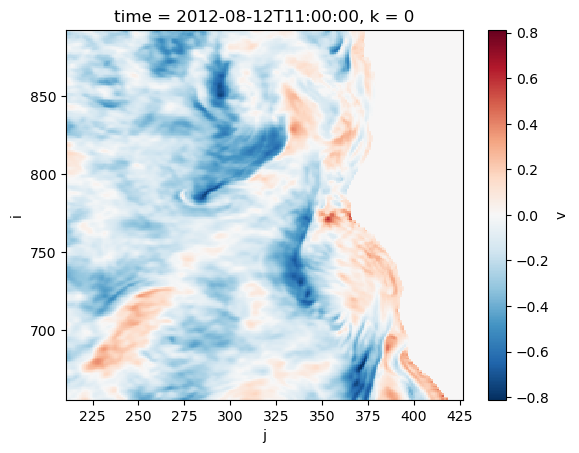

In [154]:
model_uv['v'].isel(time=923).plot()

### Flow imbalance calculation
Flow imbalance is given by,
### $\epsilon = \frac{\frac{\partial (\nabla_{h}  \cdot (\mathbf{u}))}{\partial t}}{f(|\zeta|+\overline{\langle \zeta^2 \rangle^{\frac{1}{2}}})}$ 
where $\nabla_{h} \cdot$ is the horizontal divergence. $\zeta$ is the vorticity. Angle brackets represent spatial average and the over bar is the temporal average. Second order averaged term is there to prevent singularities.

In [ ]:
vorticity = vort_div['vorticity'].where(np.isfinite(land_mask))
div = vort_div['divergence'].where(np.isfinite(land_mask))

In [32]:
#need to multiply vorticity by f, since "vorticity" is technically zeta/f, so zeta/f*f = zeta
vort_2_ave_ave = np.sqrt(((vorticity*f[:-1,:-1])**2).mean(dim='i',skipna='True').mean(dim='j',skipna=True)).mean(dim='time')

In [33]:
d_time = vort_div['time'].diff(dim='time')/np.timedelta64(1,'s')

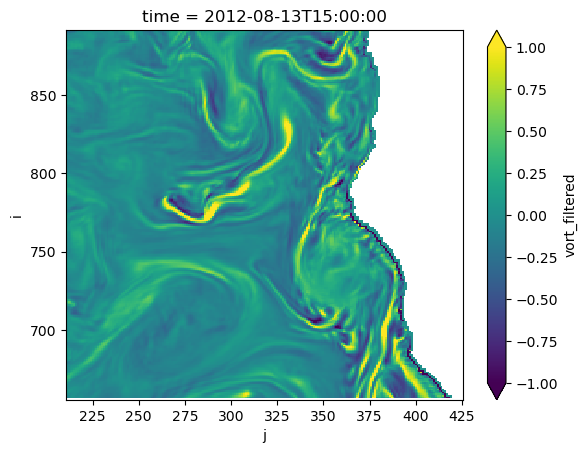

In [34]:
#again 'divergence' is technically delta/f so need to multiply by f to get delta
epsilon = ((vort_div['divergence']*f[:-1,:-1]).diff(dim='time')/d_time)/(f[:-1,:-1]*(np.abs(vort_div['vorticity']*f[:-1,:-1])+vort_2_ave_ave))

In [8]:
vort_div = xr.open_dataset(cutout_path+'vorticity_divergence.nc')#.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

In [17]:
#Need to filter out higher frequancy motions


split = '2012-03-11T02:00:00'
vort_div_first = vort_div.sel(time=slice('2011-11-01T00:00:00.000000000',split))
vort_div_last = vort_div.sel(time=slice(split,'2012-11-14T23:00:00.000000000'))
divergence_first = vort_div_first['divergence']
divergence_last = vort_div_last['divergence']

vorticity_first = vort_div_first['vorticity']
vorticity_last = vort_div_last['vorticity']


vort_div_last.sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))

<xarray.Dataset>
Dimensions:     (time: 1392, i: 236, j: 215)
Coordinates:
  * time        (time) datetime64[ns] 2012-07-05 ... 2012-08-31T23:00:00
  * i           (i) int64 656 657 658 659 660 661 ... 886 887 888 889 890 891
  * j           (j) int64 211 212 213 214 215 216 ... 420 421 422 423 424 425
Data variables:
    divergence  (time, i, j) float64 ...
    vorticity   (time, i, j) float64 ...

In [18]:
vort = vort_div_last['vorticity'].sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))
land_mask['i'] = vort['i']
land_mask['j'] = vort['j']
vort_filt = tools.filt(vort,T=15,filter_name='lancz').rename('vort_filtered').where(np.isfinite(land_mask))
div = vort_div_last['divergence'].sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))
div_filt = tools.filt(vort,T=15,filter_name='lancz').rename('div_filtered').where(np.isfinite(land_mask))

In [19]:
vort_2_ave_ave = np.sqrt(((vort_filt*f[:-1,:-1])**2).mean(dim='i',skipna='True').mean(dim='j',skipna=True)).mean(dim='time')

d_time = vort['time'].diff(dim='time')/np.timedelta64(1,'s')

In [ ]:
# vort_filt = xr.concat([tools.filt(vorticity_first,T=15,filter_name='lancz'),tools.filt(vorticity_last,T=15,filter_name='lancz')],dim='time').rename('vort_filtered').sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1])).isel(time=950)
# div_filt = xr.concat([tools.filt(divergence_first,T=15,filter_name='lancz'),tools.filt(divergence_last,T=15,filter_name='lancz')],dim='time').rename('div_filtered').sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))


In [20]:
epsilon = ((div_filt*f[:-1,:-1]).diff(dim='time')/d_time)/(f[:-1,:-1]*(np.abs(vort_filt*f[:-1,:-1])+vort_2_ave_ave))

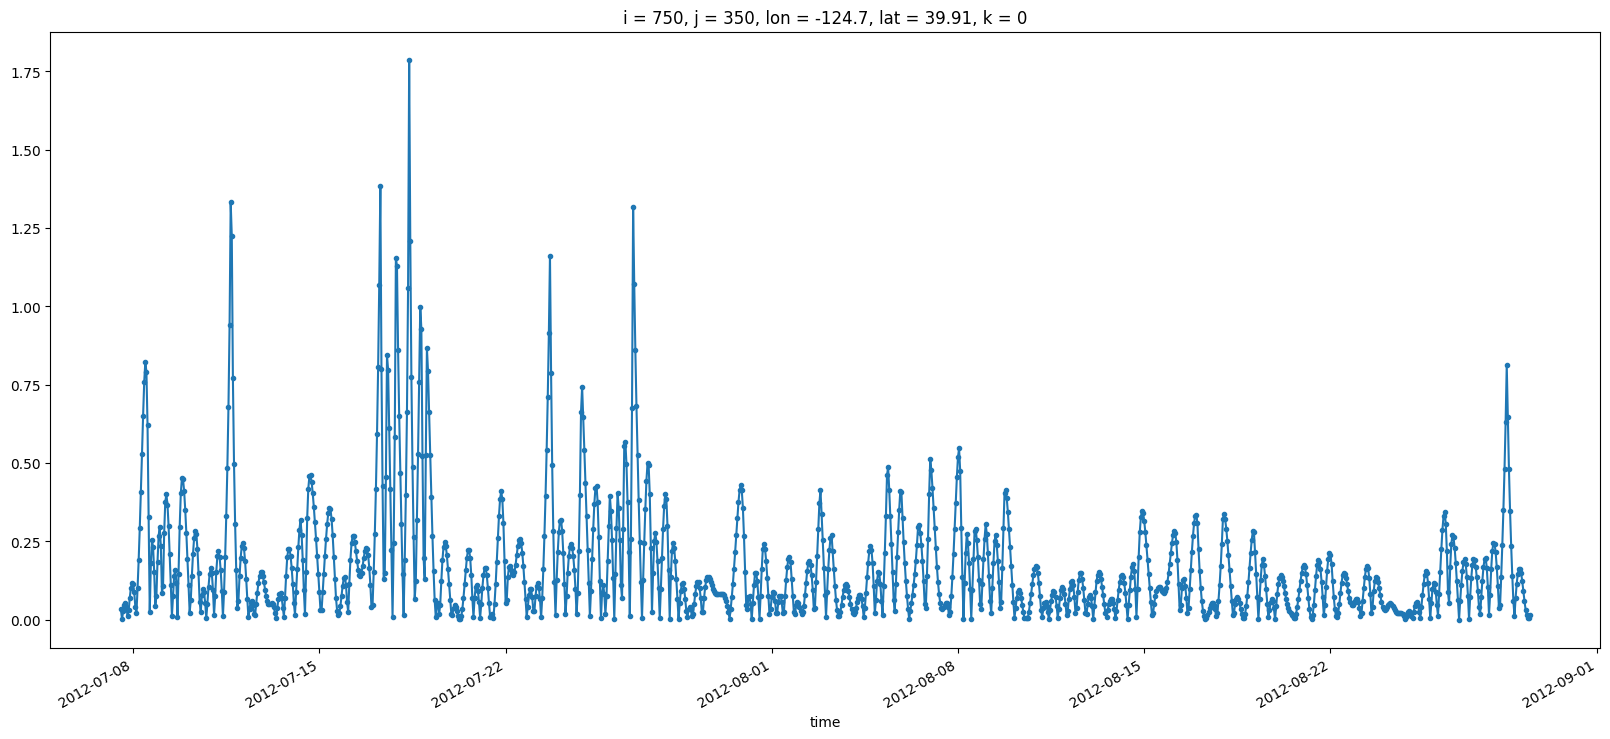

In [21]:
plt.figure(figsize=(20,8))
(np.abs(epsilon).sel(i=750,j=350)).plot(marker='.')

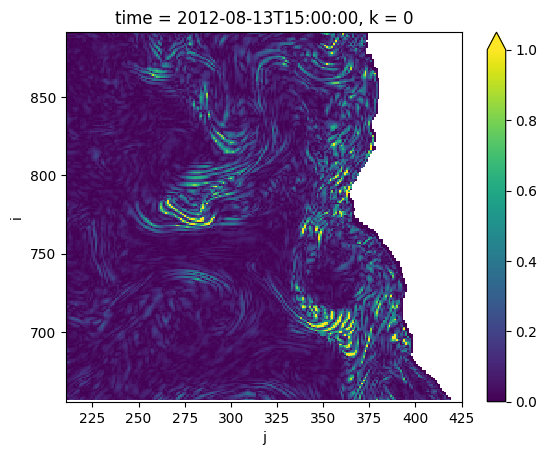

In [23]:
(np.abs(epsilon).isel(time=950)).plot(vmax=1)

In [24]:
epsilon.to_netcdf(cutout_path+'flow_imbalance_cs.nc')

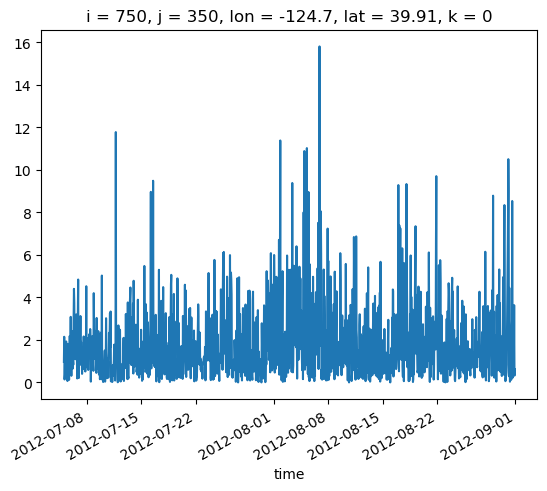

In [55]:
(np.abs(epsilon).sel(i=750,j=350)).plot()

In [ ]:
vort_filt

In [ ]:
div_filt = xr.concat([tools.filt(divergence_first,T=3,filter_name='lancz'),tools.filt(divergence_last,T=3,filter_name='lancz')],dim='time').rename('div_filtered').sel(time=slice(case_study_range_eddy[0],case_study_range_eddy[1]))


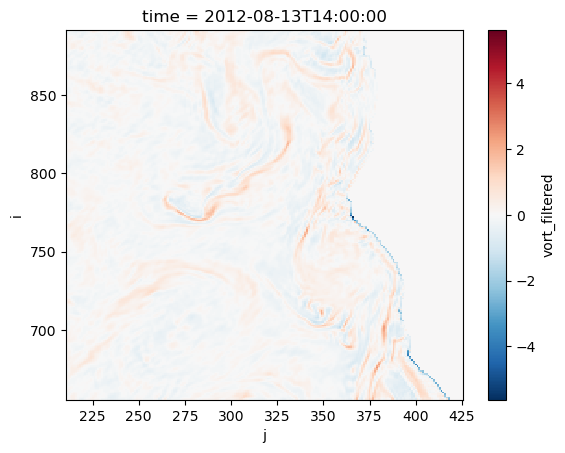

In [22]:
vort_filt.isel(time=950).plot()

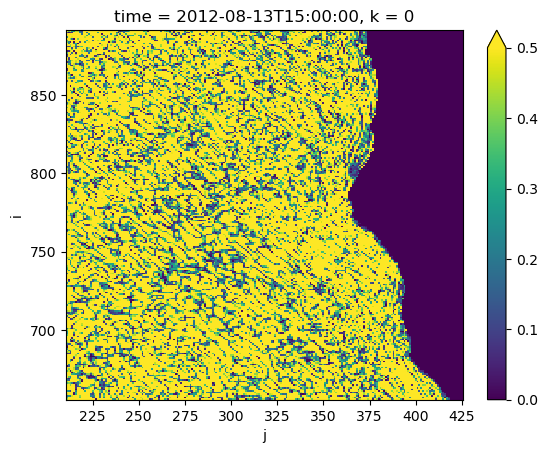

In [171]:
(np.abs(epsilon).isel(time=950)).plot(vmax=.5)

In [172]:
filt

array([0.51932302, 0.70404845, 0.83081656, ..., 0.53326363, 0.55871245,
       0.54427548])